# 04 · 2D maps, 3D maps, and a space–time cube

**Time:** 35 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Choose a visual encoding that answers a question without confusing time, value, and physical height.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=04_maps_and_cubes.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Three vertical axes, three meanings

In the **extruded map**, height encodes a scaled value. In the **time cube**, height encodes a time index.
In the **value surface**, height is a scaled measurement. Geographic coordinates remain horizontal.
The cube spaces available time indices equally; the selected WOfS dates happen to be two years apart.
Never interpret an index axis as elapsed time for irregular data.

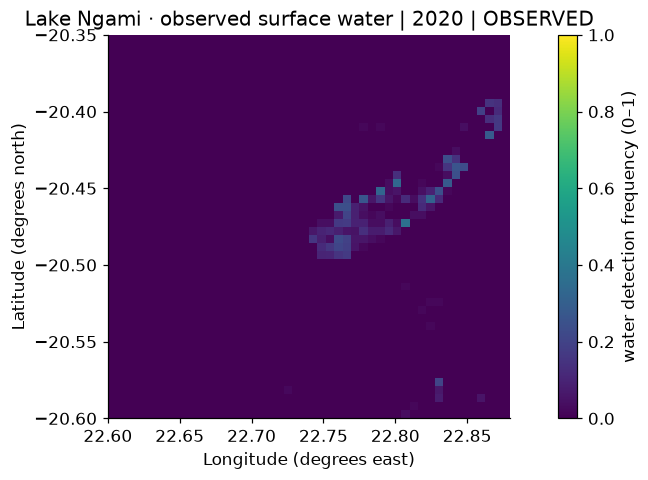

In [2]:
meta, water = load_cube('ngami')
map_slice(meta, water, 1); plt.show()

## 2. Construct a small cube in Python

Reduce point density for a clear static figure. A viewer can otherwise confuse occlusion with missing data.
Points below a threshold are hidden by design; add that fact to the caption.

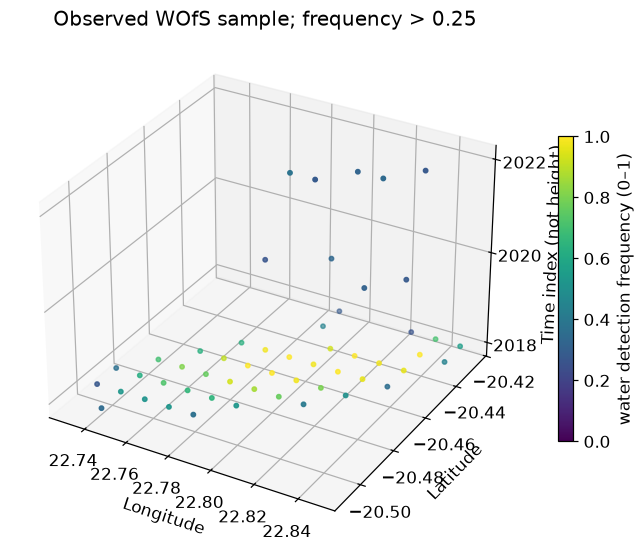

In [3]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
t, y, x = np.indices(water.shape)
keep = np.isfinite(water) & (water > 0.25) & (x % 2 == 0) & (y % 2 == 0)
points = ax.scatter(np.asarray(meta['lon'])[x[keep]], np.asarray(meta['lat'])[y[keep]], t[keep], c=water[keep], vmin=0, vmax=1, cmap='viridis', s=8)
ax.set(xlabel='Longitude', ylabel='Latitude', zlabel='Time index (not height)', title='Observed WOfS sample; frequency > 0.25')
ax.set_zticks(range(3), meta['times'])
fig.colorbar(points, ax=ax, shrink=.6, label=meta['units'])
plt.show()

## 3. Use interaction to test your first impression

Rotate the cube, switch to 2D, and click a location. Is the apparently persistent feature present at every time?
Try `value > 0.75`. Compare what the 3D view reveals with what it hides.

In [4]:
lab('ngami','cube')

## 4. Make a shareable selection

This export records time, value, origin, and license. It exports sampled points, not polygons with valid area.
Download it from the JupyterLite file browser, or use the lab’s GeoJSON button.

In [5]:
n = export_geojson(meta, water, 'ngami-water-points.geojson', threshold=.75)
print('Exported',n,'sample points')

Exported 78 sample points


## Try it yourself

Write one question best served by 2D, one by a time series, and one by a cube. Provide an accessible text description of each.

## Check your reasoning

2D supports location comparison; series supports temporal change at a point or region; a cube reveals patterns across location and time but introduces occlusion.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [zarr-sql-views, source architecture and ISC license](https://github.com/dzole0311/zarr-sql-views)
- [Digital Earth Africa WOfS specifications and limitations](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html), CC BY 4.0 data.
- [deck.gl OrbitView](https://deck.gl/docs/api-reference/core/orbit-view)

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.